## Playing with the zeros of Riemann zeta function.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import plotly.express as px
pd.set_option("display.precision", 7)
zlist=pd.read_csv("/home/student/Downloads/zeros1.csv")
zlist.head()

,zero_loc
0,14.1347251
1,21.0220396
2,25.0108576
3,30.4248761
4,32.9350616


In [2]:
nor=150 #number of readings
M=zlist[0:nor]
udd=6 #upto_decimal_digit
for d in range(0,6):
    H=zlist[0:nor]
    H=(((H[0:nor]*10**d)%1)*10)//1
    H.rename(columns = {'zero_loc':str(d+1)+'_digit'}, inplace = True)
    M=M.join(H[str(d+1)+'_digit'])
M

,zero_loc,1_digit,2_digit,3_digit,4_digit,5_digit,6_digit
0,14.1347251,1.0,3.0,4.0,7.0,2.0,5.0
1,21.0220396,0.0,2.0,2.0,0.0,3.0,9.0
2,25.0108576,0.0,1.0,0.0,8.0,5.0,7.0
3,30.4248761,4.0,2.0,4.0,8.0,7.0,6.0
4,32.9350616,9.0,3.0,5.0,0.0,6.0,1.0
...,...,...,...,...,...,...,...
145,312.4278012,4.0,2.0,7.0,8.0,0.0,1.0
146,313.9852857,9.0,8.0,5.0,2.0,8.0,5.0
147,315.4756161,4.0,7.0,5.0,6.0,1.0,6.0
148,317.7348059,7.0,3.0,4.0,8.0,0.0,5.0


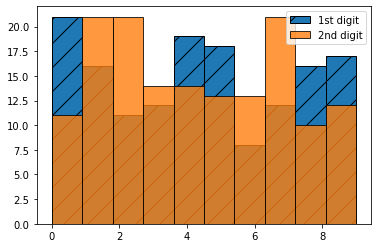

In [3]:
plt.figure()
plt.hist(M['1_digit'],bins=10, edgecolor='black', label='1st digit', hatch='/')
plt.hist(M['2_digit'],bins=10, edgecolor='black',alpha=.8, label='2nd digit')
plt.legend()
plt.show()

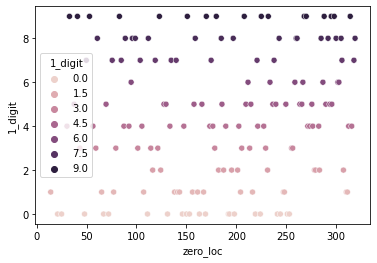

In [4]:
import seaborn as sns
plt.figure(figsize=(6,4))
sns.scatterplot(data=M,x='zero_loc',y='1_digit',hue='1_digit')
plt.show()

In [5]:
#M.reset_index(level=0, inplace=True)
#M['index']
#M.index+=1
M.insert(0, 'zero_num', [i for i in range(1,nor+1)])
M
#M.rename(columns={'index':''})

,zero_num,zero_loc,1_digit,2_digit,3_digit,4_digit,5_digit,6_digit
0,1,14.1347251,1.0,3.0,4.0,7.0,2.0,5.0
1,2,21.0220396,0.0,2.0,2.0,0.0,3.0,9.0
2,3,25.0108576,0.0,1.0,0.0,8.0,5.0,7.0
3,4,30.4248761,4.0,2.0,4.0,8.0,7.0,6.0
4,5,32.9350616,9.0,3.0,5.0,0.0,6.0,1.0
...,...,...,...,...,...,...,...,...
145,146,312.4278012,4.0,2.0,7.0,8.0,0.0,1.0
146,147,313.9852857,9.0,8.0,5.0,2.0,8.0,5.0
147,148,315.4756161,4.0,7.0,5.0,6.0,1.0,6.0
148,149,317.7348059,7.0,3.0,4.0,8.0,0.0,5.0


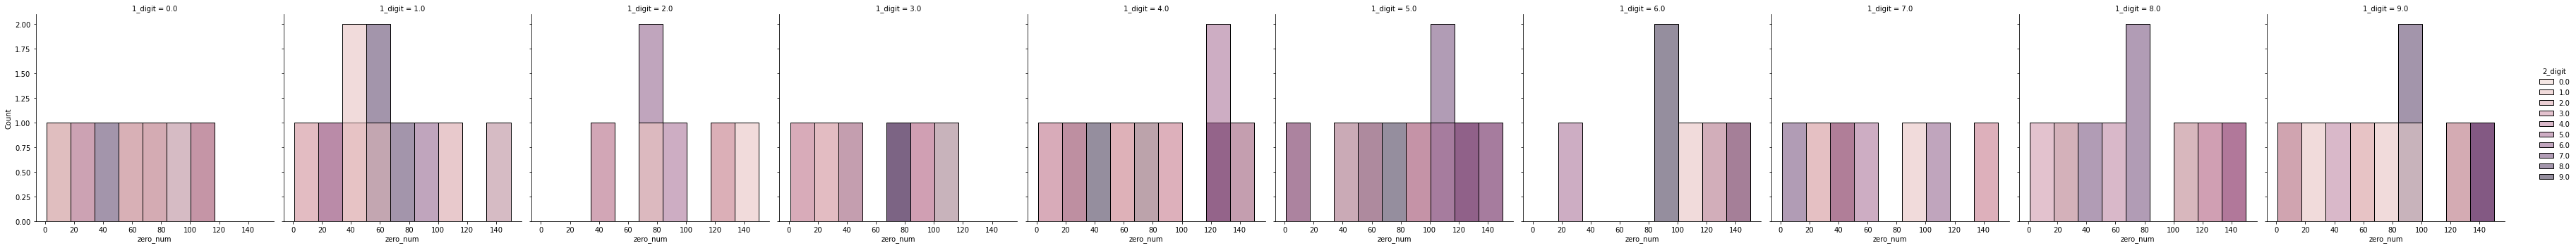

In [6]:
g=sns.displot(data=M,x='zero_num',col='1_digit',hue='2_digit')

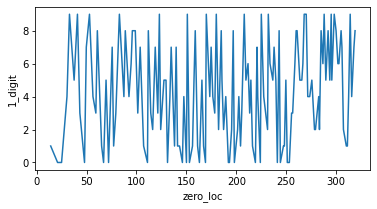

In [7]:
plt.figure(figsize=(6,3))
sns.lineplot(data=M,x='zero_loc',y='1_digit')
plt.show()

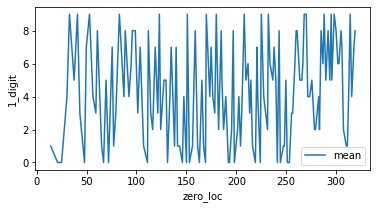

In [8]:
fig=plt.figure(figsize=(6,3))
ax=fig.add_subplot()
sns.lineplot(data=M,x='zero_loc',y='1_digit',estimator='mean',label='mean',ax=ax)
#sns.lineplot(data=M,x='zero_loc',y='1_digit',estimator='median',label='median',ax=ax)
ax.legend()
plt.show()

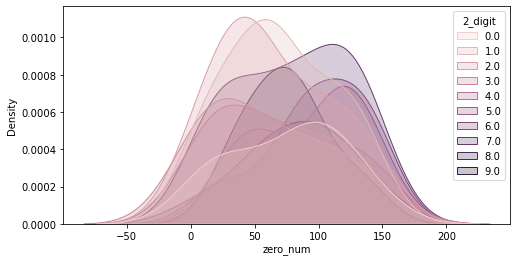

In [9]:
plt.figure(figsize=(8,4))
sns.kdeplot(data=M,x='zero_num',hue='2_digit',fill=True)
plt.show()

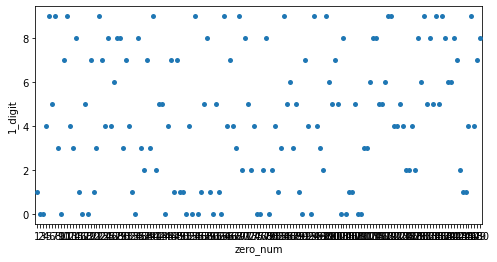

In [10]:
plt.figure(figsize=(8,4))
sns.stripplot(data=M,x='zero_num',y='1_digit')
plt.show()

In [11]:
count = M['1_digit'].value_counts()
print(count)

0.0    21
4.0    19
5.0    18
9.0    17
1.0    16
8.0    16
3.0    12
7.0    12
2.0    11
6.0     8
Name: 1_digit, dtype: int64


In [12]:
df=M
for i in range(1,6):
    for j in range(0,10):
        df[str(i)+'_digit_cc'+str(j)] = (df[str(i)+'_digit'] == j).cumsum()
#df.drop(['1_digit_cum_count', 'COUNTIF'], axis=1, inplace = True)
df

,zero_num,zero_loc,1_digit,2_digit,3_digit,4_digit,5_digit,6_digit,1_digit_cc0,1_digit_cc1,...,5_digit_cc0,5_digit_cc1,5_digit_cc2,5_digit_cc3,5_digit_cc4,5_digit_cc5,5_digit_cc6,5_digit_cc7,5_digit_cc8,5_digit_cc9
0,1,14.1347251,1.0,3.0,4.0,7.0,2.0,5.0,0,1,...,0,0,1,0,0,0,0,0,0,0
1,2,21.0220396,0.0,2.0,2.0,0.0,3.0,9.0,1,1,...,0,0,1,1,0,0,0,0,0,0
2,3,25.0108576,0.0,1.0,0.0,8.0,5.0,7.0,2,1,...,0,0,1,1,0,1,0,0,0,0
3,4,30.4248761,4.0,2.0,4.0,8.0,7.0,6.0,2,1,...,0,0,1,1,0,1,0,1,0,0
4,5,32.9350616,9.0,3.0,5.0,0.0,6.0,1.0,2,1,...,0,0,1,1,0,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,146,312.4278012,4.0,2.0,7.0,8.0,0.0,1.0,21,16,...,16,13,15,13,16,17,9,14,15,18
146,147,313.9852857,9.0,8.0,5.0,2.0,8.0,5.0,21,16,...,16,13,15,13,16,17,9,14,16,18
147,148,315.4756161,4.0,7.0,5.0,6.0,1.0,6.0,21,16,...,16,14,15,13,16,17,9,14,16,18
148,149,317.7348059,7.0,3.0,4.0,8.0,0.0,5.0,21,16,...,17,14,15,13,16,17,9,14,16,18


/home/student/.local/lib/python3.10/site-packages/numpy/core/fromnumeric.py:84: FutureWarning: In a future version, DataFrame.min(axis=None) will return a scalar min over the entire DataFrame. To retain the old behavior, use 'frame.min(axis=0)' or just 'frame.min()'
  return reduction(axis=axis, out=out, **passkwargs)
/home/student/.local/lib/python3.10/site-packages/numpy/core/fromnumeric.py:84: FutureWarning: In a future version, DataFrame.max(axis=None) will return a scalar max over the entire DataFrame. To retain the old behavior, use 'frame.max(axis=0)' or just 'frame.max()'
  return reduction(axis=axis, out=out, **passkwargs)


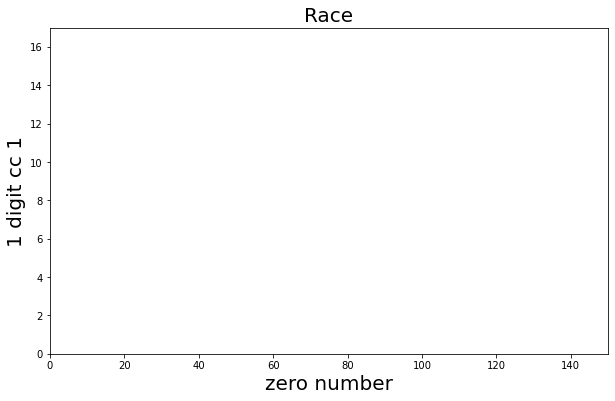

In [13]:
title='1_digit_cc1'
x = np.array(df['zero_num'])
y = np.array(df['1_digit_cc1'])
racedf = pd.DataFrame(y,x)
racedf.columns={'1_digit_cc1'}
Writer = animation.writers['ffmpeg']
writer = Writer(fps=20, metadata=dict(artist='Me'), bitrate=1800)
fig = plt.figure(figsize=(10,6))
plt.xlim(0, nor)
plt.ylim(np.min(racedf)[0]-1, np.max(racedf)[0]+1)
plt.xlabel('zero number',fontsize=20)
plt.ylabel('1 digit cc 1',fontsize=20)
plt.title('Race',fontsize=20)
sns.set(rc={'axes.facecolor':'white', 'figure.facecolor':'lightyellow','figure.edgecolor':'green','axes.grid':False})
# def animate(i):
#     data = racedf.iloc[:int(i+1)] #select data range
#     p = sns.lineplot(x=data.index, y=data[title], data=data, color="r")
#     p.tick_params(labelsize=12)
#     plt.setp(p.lines,linewidth=1)
# ani = matplotlib.animation.FuncAnimation(fig, animate, frames=nor, repeat=True)
# ani.save('Race11.mp4', writer=writer)

In [64]:
## Creating a line chart of MSFT and AAPL stock prices
## with px

## Call px.line
fig = px.line(df,                 ## First input the data
              x='zero_num',           ## Then the desired horizontal variable
              y=['1_digit_cc1', '2_digit_cc1', '3_digit_cc1','4_digit_cc1','5_digit_cc1'],\
             ) ## When wanting to plot multiple columns as lines at once
                                  ## input a list of column names
#fig.update_traces(selector={'name':'1_digit_cc1'},line={'dash':'dash'})
fig.update_layout(hovermode='x')


newnames = {'1_digit_cc1':'Player A', '2_digit_cc1':'Player B', '3_digit_cc1':'Player C','4_digit_cc1':'Player D','5_digit_cc1':'Player E'}
fig.for_each_trace(lambda t: t.update(name = newnames[t.name],
                                      legendgroup = newnames[t.name],
                                      hovertemplate = t.hovertemplate.replace(t.name, newnames[t.name])
                                     )
                  )
fig.update_layout(
    title="Race 1",
    xaxis_title="No of zeros crossed",
    yaxis_title="No of 1 Collected",
    legend_title="Players List ",
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    font=dict(
        family="Courier New, monospace",
        size=18,
        color="RebeccaPurple"
    )
)
fig.update_xaxes(linecolor="blue",linewidth=2)
fig.update_yaxes(linecolor="blue",linewidth=2)
## This displays the Figure
fig.show()
fig.write_html("graph_11.html")

In [66]:
for i in range(0,10):
    fig = px.line(df,                 ## First input the data
              x='zero_num',           ## Then the desired horizontal variable
              y=['1_digit_cc'+str(i), '2_digit_cc'+str(i), '3_digit_cc'+str(i),'4_digit_cc'+str(i),'5_digit_cc'+str(i)],\
             ) ## When wanting to plot multiple columns as lines at once
                                      ## input a list of column names
    #fig.update_traces(selector={'name':'1_digit_cc1'},line={'dash':'dash'})
    fig.update_layout(hovermode='x')


    newnames = {'1_digit_cc'+str(i):'Player A', '2_digit_cc'+str(i):'Player B', '3_digit_cc'+str(i):'Player C','4_digit_cc'+str(i):'Player D','5_digit_cc'+str(i):'Player E'}
    fig.for_each_trace(lambda t: t.update(name = newnames[t.name],
                                          legendgroup = newnames[t.name],
                                          hovertemplate = t.hovertemplate.replace(t.name, newnames[t.name])
                                         )
                      )
    fig.update_layout(
        title="Race "+str(i),
        xaxis_title="No of zeros crossed",
        yaxis_title="No of "+str(i)+" Collected",
        legend_title="Players List ",
        paper_bgcolor='rgba(0,0,0,0)',
        plot_bgcolor='rgba(0,0,0,0)',
        font=dict(
            family="Courier New, monospace",
            size=18,
            color="RebeccaPurple"
        )
    )
    fig.update_xaxes(linecolor="blue",linewidth=2)
    fig.update_yaxes(linecolor="blue",linewidth=2)
    ## This displays the Figure
    fig.show()
    #/home/student/githubsynced/Suraj-Singh-Khurana.github.io/checkhtml/
    fig.write_html("Race"+str(i)+".html",include_plotlyjs="cdn")
    

In [74]:
df.at[149,"2_digit_cc1"]

21

In [65]:
'1_digit_cc'+str(0)

'1_digit_cc0'

In [15]:
fig = px.bar(df,                 ## First input the data
              y='zero_num',           ## Then the desired horizontal variable
              x=['1_digit_cc1', '2_digit_cc1', '3_digit_cc1','4_digit_cc1','5_digit_cc1'],\
             ) ## When wanting to plot multiple columns as lines at once
                                  ## input a list of column names
#fig.update_traces(selector={'name':'1_digit_cc1'},line={'dash':'dash'})
#fig.update_layout(hovermode='x unified')
## This displays the Figure
fig.show()

In [16]:
import plotly.graph_objects as go

digits = ['0','1', '2', '3', '4', '5',
          '6', '7', '8', '9']
y_1=[];
for i in range(0,10):
    y_1.append(df.at[nor-1,'1_digit_cc'+str(i)])
fig = go.Figure()
fig.add_trace(go.Bar(
    x=digits,
    y=y_1 ,
    name='Player 1',
    marker_color='indianred'
))

y_2=[];
for i in range(0,10):
    y_2.append(df.at[nor-1,'2_digit_cc'+str(i)])
    
fig.add_trace(go.Bar(
    x=digits,
    y=y_2,
    name='Player 2',
    marker_color='lightsalmon'
))

# Here we modify the tickangle of the xaxis, resulting in rotated labels.
fig.update_layout(barmode='group', xaxis_tickangle=-45)
fig.show()

In [17]:
for i in range(0,nor):
    y_1=y_1.append(df.at[nor-1,'1_digit_cc'+str(i)])

AttributeError: 'NoneType' object has no attribute 'append'

In [23]:
import plotly.graph_objects as go
from ipywidgets import widgets
from IPython.display import display, clear_output

P1 = widgets.Dropdown(
    description='Player:   ',
    value='Player A',
    options=['Player A','Player A','Player A','Player A','Player A']
)
P2 = widgets.Dropdown(
    description='Player:   ',
    value='Player A',
    options=['Player A','Player A','Player A','Player A','Player A']
)

In [50]:
P1 = widgets.Dropdown(
    description='Player:   ',
    value='A',
    options=['A','B','C','D','E']
)
P2 = widgets.Dropdown(
    description='Player:   ',
    value='B',
    options=['A','B','C','D','E']
)
digits = ['0','1', '2', '3', '4', '5',
          '6', '7', '8', '9']

# Define function to update the graph based on dropdown selections
def update_graph(change):
    playerA = P1.value
    playerB = P2.value
    output.clear_output()
    with output:
        y_1=[];
        for i in range(0,10):
            y_1.append(df.at[nor-1,'1_digit_cc'+str(i)])
        fig = go.Figure()
        fig.add_trace(go.Bar(
            x=digits,
            y=y_1 ,
            name='Player 1',
            marker_color='indianred'
        ))
        y_2=[];
        for i in range(0,10):
            y_2.append(df.at[nor-1,'2_digit_cc'+str(i)])

        fig.add_trace(go.Bar(
            x=digits,
            y=y_2,
            name='Player 2',
            marker_color='lightsalmon'
        ))

        # Here we modify the tickangle of the xaxis, resulting in rotated labels.
        fig.update_layout(barmode='group', xaxis_tickangle=-45, xaxis_title='zero_num', yaxis_title='value')
        fig.show()
# Display the dropdowns and initial graph
output = widgets.Output()

# display(P1)
# display(P2)

# Set up event handlers to update the graph when the dropdowns change


P1.observe(update_graph, names='value')
P2.observe(update_graph, names='value')

display(widgets.HBox([P1, P2]))
display(output)

Output()

In [51]:
P1.value

'A'

In [42]:
import plotly.graph_objects as go
from ipywidgets import widgets
from IPython.display import display, clear_output

# Create dropdown widgets
x_dropdown = widgets.Dropdown(
    options=['x1', 'x2', 'x3'],
    value='x1',
    description='X-axis:'
)

y_dropdown = widgets.Dropdown(
    options=['y1', 'y2', 'y3'],
    value='y1',
    description='Y-axis:'
)

# Define function to update the graph based on dropdown selections
def update_graph(x_axis, y_axis):
    clear_output(wait=True)  # Clear previous output
    fig = go.Figure(data=go.Scatter(x=[1, 2, 3], y=[4, 5, 6]))
    fig.update_layout(xaxis_title=x_axis, yaxis_title=y_axis)
    fig.show()

# Display the dropdowns and initial graph
display(widgets.HBox([x_dropdown, y_dropdown]))
update_graph(x_dropdown.value, y_dropdown.value)

# Set up event handlers to update the graph when the dropdowns change
def on_x_dropdown_change(change):
    update_graph(change.new, y_dropdown.value)

def on_y_dropdown_change(change):
    update_graph(x_dropdown.value, change.new)

x_dropdown.observe(on_x_dropdown_change, names='value')
y_dropdown.observe(on_y_dropdown_change, names='value')

In [34]:
import ipywidgets as widgets

# Define the dropdown options
options = ['Option 1', 'Option 2', 'Option 3']

# Create the dropdown widgets
dropdown1 = widgets.Dropdown(options=options, value=options[0], description='Dropdown 1:')
dropdown2 = widgets.Dropdown(options=options, value=options[0], description='Dropdown 2:')

# Arrange the dropdowns horizontally using a HBox layout
display(widgets.HBox([dropdown1, dropdown2]))
